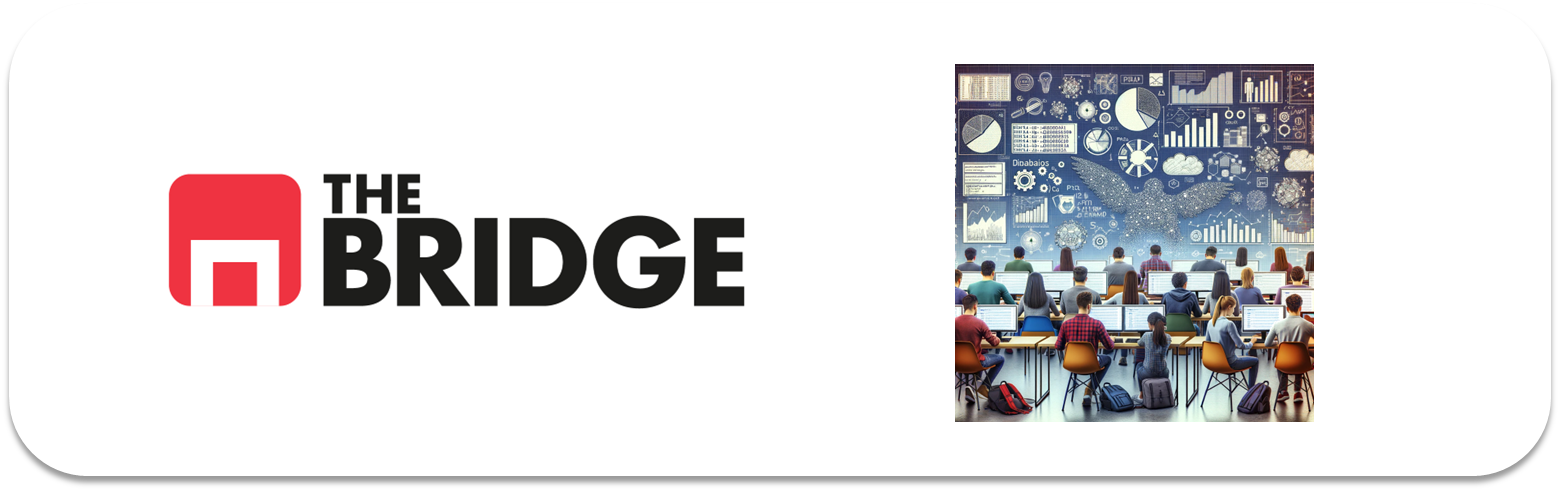

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("data/hard_to_find/obligatoria_hard.csv", sep="|")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [3]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


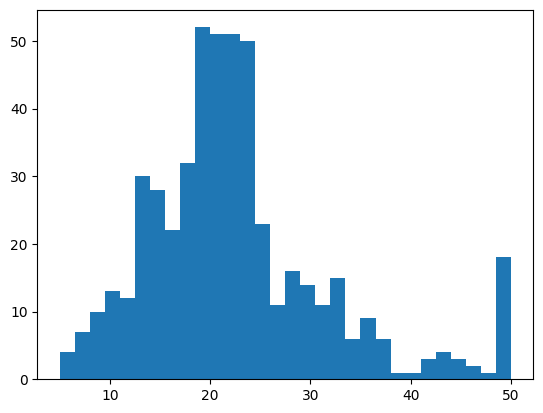

In [4]:
plt.hist(df["MEDV"], bins=30)
plt.show()

Es apta para regresión lineal, aunque hay un grupo acumulado al final que parece ser un "capado" artificial.  
Voy a quitarlo para que la gráfica sea más campana de gauss. Desconozco si es una buena práctica, pero creo que hay bastantes datos para entrenar al modelo por debajo de 50k

In [5]:
df = df[df["MEDV"] < 50]
df.shape

(490, 13)

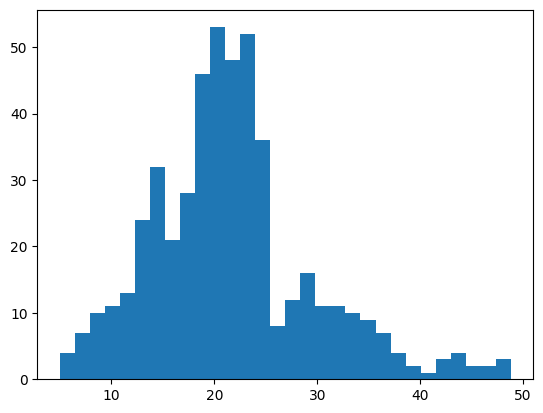

In [6]:
plt.hist(df["MEDV"], bins=30)
plt.show()

In [7]:
# El split
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(392, 12)
(98, 12)


In [8]:
features = X_train.columns

features

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT'],
      dtype='str')

In [9]:
# serie_corr = np.abs(corr[y]).sort_values(ascendig=False)
# serie_corr

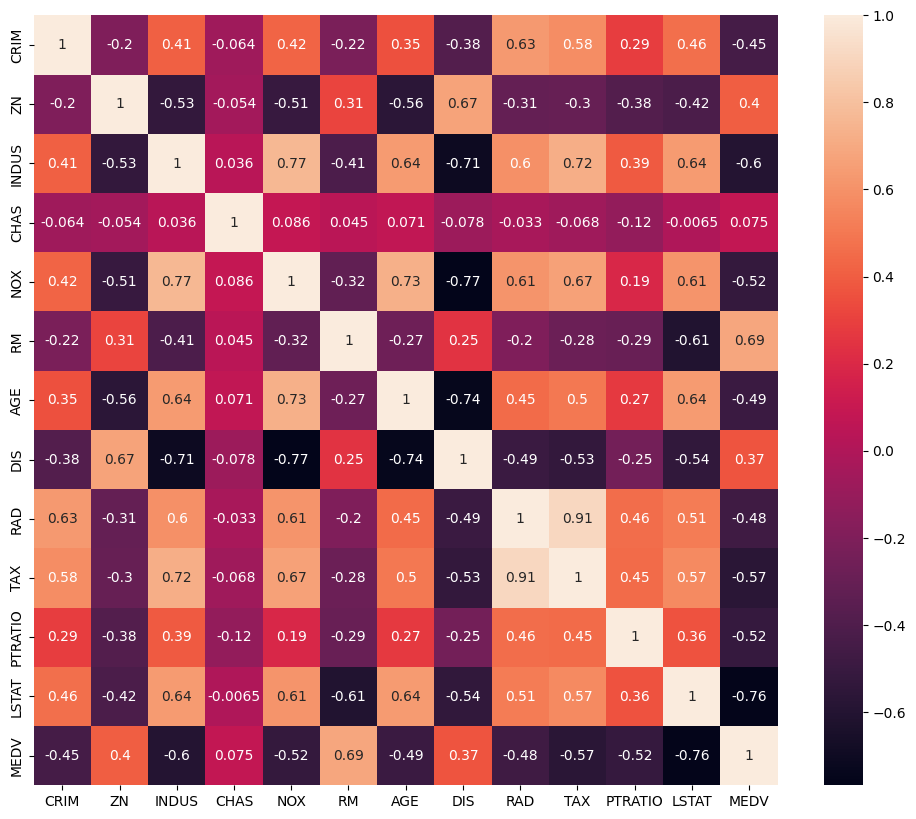

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only = True),annot=True,)
plt.show()

In [11]:
# Colinearidad: "Ver si son la misma columna con distinto nombre"
# Este apartado está hecho en clase

criterio_col = 0.7
excluidas = []
corr_numeric = X_train[features].corr(numeric_only = True)

for col in features:
    print(f"Comprobando colinealidad de {col}")
    if col not in excluidas:
        for col_2, valor_corr in corr_numeric[col].items():
            print(f"\tComprobando {col} con {col_2}")
            if col != col_2 and col_2 in features:
                if np.abs(valor_corr) >= criterio_col:
                    print(f"\t\t--> {col} correla con {col_2} al {valor_corr:0.4f}, EXCLUIMOS {col_2} <--")
                    excluidas.append(col_2)
                else:
                    print(f"\t\t{col} correla con {col_2} al {valor_corr:0.4f}, mantenemos {col_2}")
            elif col == col_2:
                print("\t\tSon la misma variable, no comprobamos")
    
    elif col in excluidas:
        print(f"\tLa columna {col} ya ha sido excluida")

excluidas = list(set(excluidas))
print("\nLas variables a excluir son", excluidas)

Comprobando colinealidad de CRIM
	Comprobando CRIM con CRIM
		Son la misma variable, no comprobamos
	Comprobando CRIM con ZN
		CRIM correla con ZN al -0.2113, mantenemos ZN
	Comprobando CRIM con INDUS
		CRIM correla con INDUS al 0.4232, mantenemos INDUS
	Comprobando CRIM con CHAS
		CRIM correla con CHAS al -0.0592, mantenemos CHAS
	Comprobando CRIM con NOX
		CRIM correla con NOX al 0.4306, mantenemos NOX
	Comprobando CRIM con RM
		CRIM correla con RM al -0.2519, mantenemos RM
	Comprobando CRIM con AGE
		CRIM correla con AGE al 0.3542, mantenemos AGE
	Comprobando CRIM con DIS
		CRIM correla con DIS al -0.3859, mantenemos DIS
	Comprobando CRIM con RAD
		CRIM correla con RAD al 0.6408, mantenemos RAD
	Comprobando CRIM con TAX
		CRIM correla con TAX al 0.6014, mantenemos TAX
	Comprobando CRIM con PTRATIO
		CRIM correla con PTRATIO al 0.2951, mantenemos PTRATIO
	Comprobando CRIM con LSTAT
		CRIM correla con LSTAT al 0.4688, mantenemos LSTAT
Comprobando colinealidad de ZN
	Comprobando ZN con

In [12]:
# Me quito algunas columnas de en medio

X_train = X_train.drop(columns=["DIS", "TAX"])
X_test = X_test.drop(columns=["DIS", "TAX"])

X_train.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'RAD', 'PTRATIO',
       'LSTAT'],
      dtype='str')

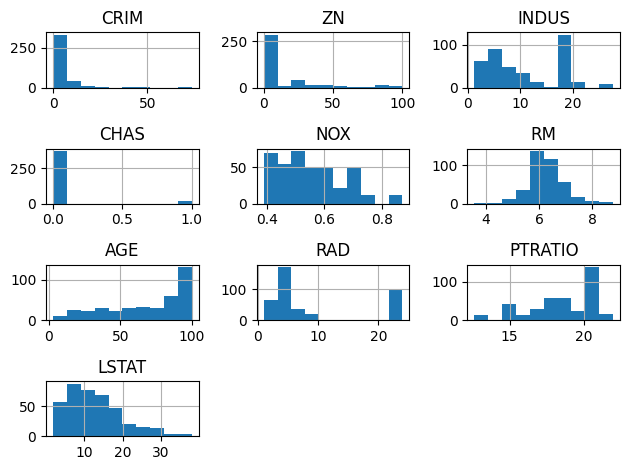

In [13]:
X_train.hist()
plt.tight_layout()

<Axes: xlabel='RAD', ylabel='Count'>

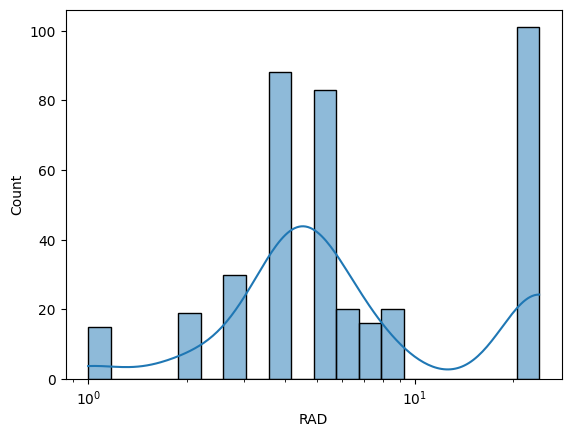

In [14]:
sns.histplot(X_train["RAD"], bins=20, kde=True, log_scale=10)

In [15]:
X_train_back = X_train.copy()

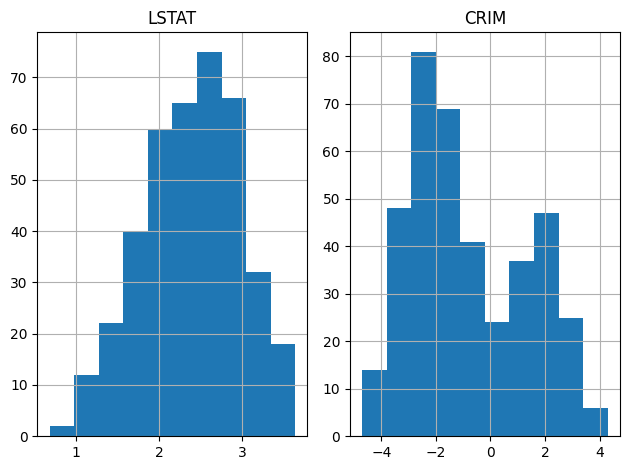

In [16]:
features_transform = ["LSTAT", "CRIM"]

for feature in features_transform:
    X_train[feature] = X_train[feature].apply(np.log)

X_train[features_transform].hist()
plt.tight_layout()

In [17]:
features_transform = ["LSTAT", "CRIM"]

for feature in features_transform:
    X_test[feature] = X_test[feature].apply(np.log)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

# Que no se me olvide más replicar en test
# Aquí no aprende (fit) como es obvio
X_test_scaled = scaler.transform(X_test)


In [19]:
# Por fin la regresión lineal

# Me ofende que con sklearn sea tan sencillo.
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
modelo.intercept_

np.float64(22.028826530612243)

In [21]:
from sklearn.metrics import median_absolute_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [29]:
pred_train = modelo.predict(X_train_scaled)

print("MAE:", mean_absolute_error(y_train, pred_train))
print("RMSE:", root_mean_squared_error(y_train, pred_train))
print("MAPE:", mean_absolute_percentage_error(y_train, pred_train))
print("R^2:", modelo.score(X_train_scaled, y_train))

MAE: 2.919840337052255
RMSE: 3.8482251027085588
MAPE: 0.15387709640529246
R^2: 0.7672578949681452


In [28]:
pred_test = modelo.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, pred_test))
print("RMSE:", root_mean_squared_error(y_test, pred_test))
print("MAPE:", mean_absolute_percentage_error(y_test, pred_test))
print("R^2:", modelo.score(X_test_scaled, y_test))

MAE: 2.808417826978103
RMSE: 3.5945625065865108
MAPE: 0.16094094016926125
R^2: 0.7470727359774538


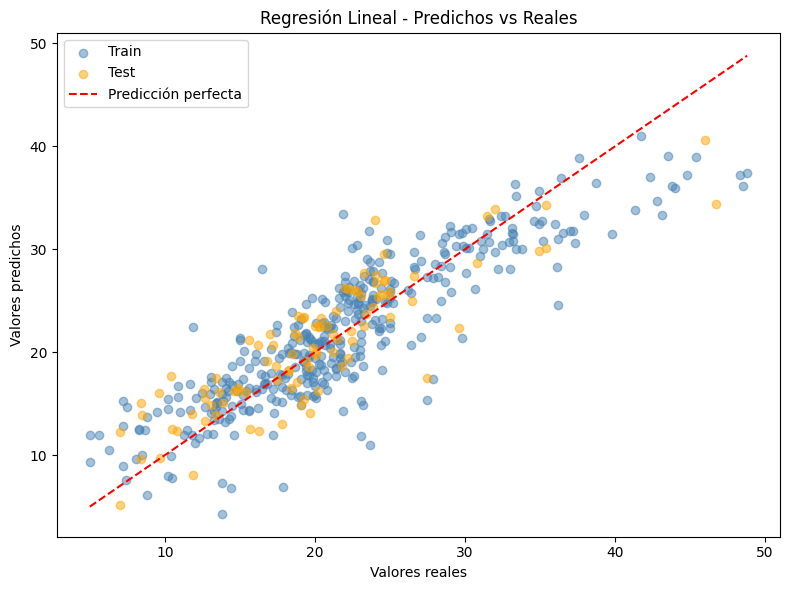

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_train, pred_train, alpha=0.5, color="steelblue", label="Train")
ax.scatter(y_test, pred_test, alpha=0.5, color="orange", label="Test")

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
ax.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Predicción perfecta")

ax.set_xlabel("Valores reales")
ax.set_ylabel("Valores predichos")
ax.set_title("Regresión Lineal - Predichos vs Reales")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge_reg = Ridge(alpha= 1)
lasso_reg = Lasso(alpha= 1)
elastic_reg = ElasticNet(alpha= 1, l1_ratio=0.5)

for nombre, model in zip(["Ridge","Lasso","ElasticNet"],[ridge_reg, lasso_reg, elastic_reg]):
    model.fit(X_train, y_train)
    print("Modelo:", nombre)
    print("TRAIN:")
    pred_train  = model.predict(X_train)
    print("\tMAE:", median_absolute_error(y_train, pred_train))
    print("\tRMSE:", root_mean_squared_error(y_train, pred_train))
    print("MAPE:", mean_absolute_percentage_error(y_train, pred_train) * 100)
    print("\tR^2:", model.score(X_train, y_train))
    print("TEST:")
    pred_test = model.predict(X_test)
    print("\tMAE:", median_absolute_error(y_test, pred_test))
    print("\tRMSE:", root_mean_squared_error(y_test, pred_test))
    print("MAPE:", mean_absolute_percentage_error(y_test, pred_test) * 100)
    print("\tR^2:", model.score(X_test, y_test))
    print("")

Modelo: Ridge
TRAIN:
	MAE: 2.242516895411871
	RMSE: 3.8515601676648297
MAPE: 15.436051264158095
	R^2: 0.7668543081878
TEST:
	MAE: 2.3367777488210244
	RMSE: 3.6243929262448065
MAPE: 16.287020266148694
	R^2: 0.7428573505500073

Modelo: Lasso
TRAIN:
	MAE: 2.853615906249183
	RMSE: 4.584480996467361
MAPE: 18.955947993042205
	R^2: 0.6696803762842425
TEST:
	MAE: 2.624750471231591
	RMSE: 4.112387647064743
MAPE: 19.286662343020954
	R^2: 0.6689514744423133

Modelo: ElasticNet
TRAIN:
	MAE: 3.0302828569581273
	RMSE: 4.893088613197135
MAPE: 19.99982725828243
	R^2: 0.6237121607469155
TEST:
	MAE: 2.867004005610019
	RMSE: 4.360677049231955
MAPE: 19.875983695431117
	R^2: 0.6277699640129246

